     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 646.0 kB/s eta 0:00:00
Fetching reviews... please wait.

--- Generating Management Summary ---


/tmp/ipykernel_5035/3222986968.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='magma')


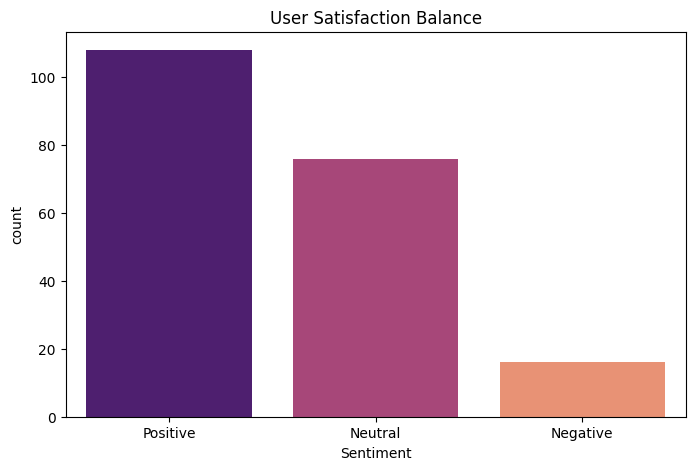

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


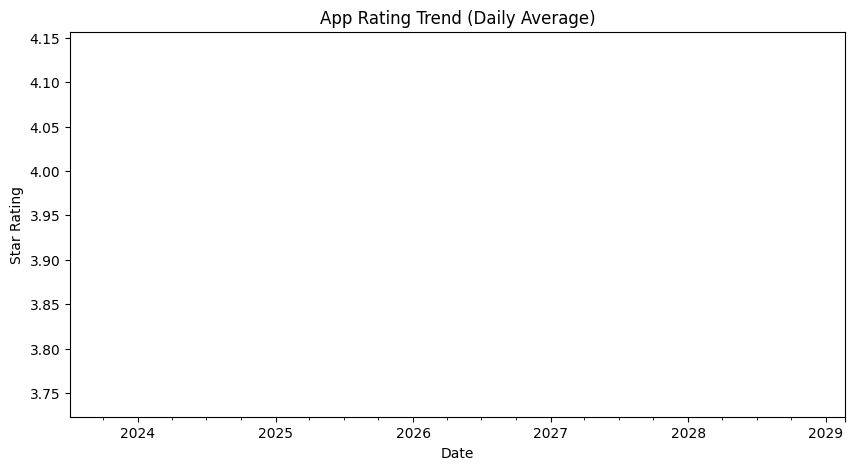


--- TOP ACTIONABLE COMPLAINTS (BIGRAMS) ---
Issue: 'disabled account' mentioned 1 times
Issue: 'account false' mentioned 1 times
Issue: 'false accusations' mentioned 1 times
Issue: 'instagram suspending' mentioned 1 times
Issue: 'suspending random' mentioned 1 times


In [2]:
!pip install google-play-scraper
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google_play_scraper import Sort, reviews
from textblob import TextBlob
import re

# ==========================================
# PHASE A: DATA COLLECTION
# ==========================================
print("Fetching reviews... please wait.")
result, _ = reviews(
    'com.instagram.android', # Change this to your target app ID
    lang='en',
    country='in',
    sort=Sort.NEWEST,
    count=200 # Starting with 200 for speed; you can increase to 1000
)

df = pd.DataFrame(result)
# Keep only what we need
df = df[['content', 'score', 'at']]
df.columns = ['Review', 'Rating', 'Date']

# ==========================================
# PHASE B: TEXT PRE-PROCESSING
# ==========================================
def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation/emojis
    return text

df['Clean_Review'] = df['Review'].apply(clean_text)

# ==========================================
# PHASE C: SENTIMENT & DISCOVERY
# ==========================================
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Clean_Review'].apply(get_sentiment)

# ==========================================
# PHASE D: INSIGHTS & VISUALIZATION
# ==========================================
print("\n--- Generating Management Summary ---")

# 1. Distribution Plot (Satisfied vs Unsatisfied)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', palette='magma')
plt.title('User Satisfaction Balance')
plt.show()

# 2. Trend Line (Sentiment over time)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date').resample('D')['Rating'].mean().plot(figsize=(10,5), color='blue')
plt.title('App Rating Trend (Daily Average)')
plt.ylabel('Star Rating')
plt.show()

# 3. Finding "Actionable Bigrams" (The 'Pain' Analysis)
# We look for pairs of words in negative reviews
from sklearn.feature_extraction.text import CountVectorizer

negative_reviews = df[df['Sentiment'] == 'Negative']['Clean_Review']

if not negative_reviews.empty:
    cv = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(negative_reviews)
    bag_of_words = cv.transform(negative_reviews)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    print("\n--- TOP ACTIONABLE COMPLAINTS (BIGRAMS) ---")
    for word, freq in words_freq[:5]:
        print(f"Issue: '{word}' mentioned {freq} times")